# Converting Time Column Based on Total Bill

This notebook demonstrates how to convert the 'time' column in the tips dataset based on the 'total_bill' values using Target Guided Ordinal Encoding.

Target Guided Ordinal Encoding is a technique where we replace each category in a categorical variable with a numerical value based on the mean or median of the target variable (in this case, total_bill) for that category.

In [1]:
# Import necessary libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

# Load the tips dataset
df = sns.load_dataset('tips')

# Display basic information about the dataset
print("Dataset shape:", df.shape)
print("\nDataset info:")
print(df.info())
print("\nFirst few rows:")
df.head()

Dataset shape: (244, 7)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None

First few rows:


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [2]:
# Explore the 'time' column
print("Unique values in 'time' column:")
print(df['time'].value_counts())
print("\nBasic statistics for total_bill:")
print(df['total_bill'].describe())

Unique values in 'time' column:
time
Dinner    176
Lunch      68
Name: count, dtype: int64

Basic statistics for total_bill:
count    244.000000
mean      19.785943
std        8.902412
min        3.070000
25%       13.347500
50%       17.795000
75%       24.127500
max       50.810000
Name: total_bill, dtype: float64


Average total_bill by time:
         mean  median   std  count
time                              
Lunch   17.17   15.96  7.71     68
Dinner  20.80   18.39  9.14    176


/var/folders/y1/44jbvlv94_5c1bldzjp1gnlh0000gn/T/ipykernel_6184/25825399.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  time_bill_analysis = df.groupby('time')['total_bill'].agg(['mean', 'median', 'std', 'count']).round(2)


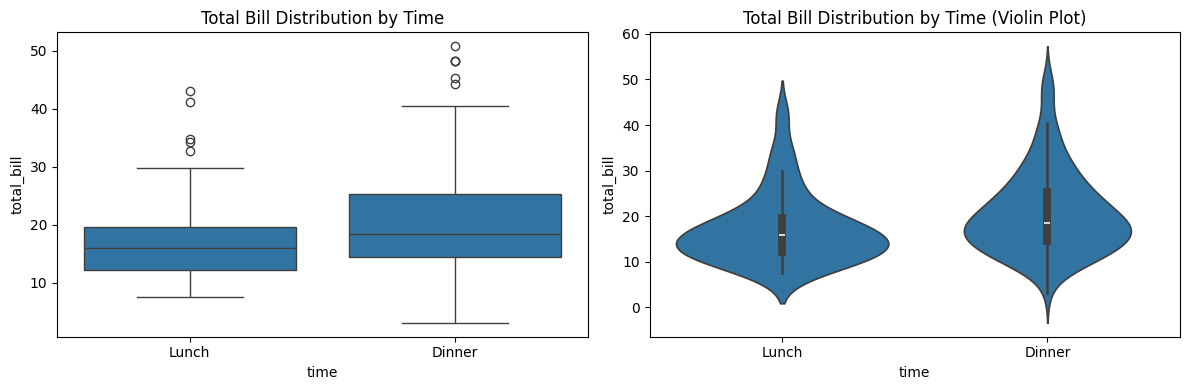

In [3]:
# Analyze the relationship between 'time' and 'total_bill'
print("Average total_bill by time:")
time_bill_analysis = df.groupby('time')['total_bill'].agg(['mean', 'median', 'std', 'count']).round(2)
print(time_bill_analysis)

# Visualize the relationship
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='time', y='total_bill')
plt.title('Total Bill Distribution by Time')

plt.subplot(1, 2, 2)
sns.violinplot(data=df, x='time', y='total_bill')
plt.title('Total Bill Distribution by Time (Violin Plot)')

plt.tight_layout()
plt.show()

In [4]:
# Method 1: Target Guided Ordinal Encoding based on mean total_bill
def target_guided_ordinal_encoding_mean(df, categorical_col, target_col):
    """
    Apply target guided ordinal encoding using mean values
    """
    # Calculate mean target value for each category
    mean_values = df.groupby(categorical_col)[target_col].mean().sort_values()
    print("Mean total_bill by time (sorted):")
    print(mean_values)
    
    # Create mapping dictionary
    encoding_map = {category: idx for idx, category in enumerate(mean_values.index)}
    
    # Apply encoding
    df[f'{categorical_col}_encoded_mean'] = df[categorical_col].map(encoding_map)
    
    return df, encoding_map

# Apply target guided ordinal encoding
df_encoded_mean, encoding_map_mean = target_guided_ordinal_encoding_mean(df.copy(), 'time', 'total_bill')
print(f"\nEncoding mapping: {encoding_map_mean}")

Mean total_bill by time (sorted):
time
Lunch     17.168676
Dinner    20.797159
Name: total_bill, dtype: float64

Encoding mapping: {'Lunch': 0, 'Dinner': 1}


/var/folders/y1/44jbvlv94_5c1bldzjp1gnlh0000gn/T/ipykernel_6184/1850654169.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_values = df.groupby(categorical_col)[target_col].mean().sort_values()


In [5]:
# Method 2: Target Guided Ordinal Encoding based on median total_bill
def target_guided_ordinal_encoding_median(df, categorical_col, target_col):
    """
    Apply target guided ordinal encoding using median values
    """
    # Calculate median target value for each category
    median_values = df.groupby(categorical_col)[target_col].median().sort_values()
    print("Median total_bill by time (sorted):")
    print(median_values)
    
    # Create mapping dictionary
    encoding_map = {category: idx for idx, category in enumerate(median_values.index)}
    
    # Apply encoding
    df[f'{categorical_col}_encoded_median'] = df[categorical_col].map(encoding_map)
    
    return df, encoding_map

# Apply target guided ordinal encoding with median
df_encoded_median, encoding_map_median = target_guided_ordinal_encoding_median(df.copy(), 'time', 'total_bill')
print(f"\nEncoding mapping: {encoding_map_median}")

Median total_bill by time (sorted):
time
Lunch     15.965
Dinner    18.390
Name: total_bill, dtype: float64

Encoding mapping: {'Lunch': 0, 'Dinner': 1}


/var/folders/y1/44jbvlv94_5c1bldzjp1gnlh0000gn/T/ipykernel_6184/1569868125.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_values = df.groupby(categorical_col)[target_col].median().sort_values()


In [6]:
# Method 3: Target Guided Ordinal Encoding based on quantiles
def target_guided_ordinal_encoding_quantile(df, categorical_col, target_col, quantile=0.75):
    """
    Apply target guided ordinal encoding using quantile values
    """
    # Calculate quantile target value for each category
    quantile_values = df.groupby(categorical_col)[target_col].quantile(quantile).sort_values()
    print(f"{quantile*100}th percentile total_bill by time (sorted):")
    print(quantile_values)
    
    # Create mapping dictionary
    encoding_map = {category: idx for idx, category in enumerate(quantile_values.index)}
    
    # Apply encoding
    df[f'{categorical_col}_encoded_quantile'] = df[categorical_col].map(encoding_map)
    
    return df, encoding_map

# Apply target guided ordinal encoding with 75th percentile
df_encoded_quantile, encoding_map_quantile = target_guided_ordinal_encoding_quantile(df.copy(), 'time', 'total_bill', 0.75)
print(f"\nEncoding mapping: {encoding_map_quantile}")

75.0th percentile total_bill by time (sorted):
time
Lunch     19.5325
Dinner    25.2825
Name: total_bill, dtype: float64

Encoding mapping: {'Lunch': 0, 'Dinner': 1}


/var/folders/y1/44jbvlv94_5c1bldzjp1gnlh0000gn/T/ipykernel_6184/3625174854.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quantile_values = df.groupby(categorical_col)[target_col].quantile(quantile).sort_values()


In [7]:
# Compare all encoding methods
print("Comparison of different encoding methods:")
comparison_df = pd.DataFrame({
    'Original_Time': df['time'],
    'Mean_Encoded': df_encoded_mean['time_encoded_mean'],
    'Median_Encoded': df_encoded_median['time_encoded_median'],
    'Quantile_Encoded': df_encoded_quantile['time_encoded_quantile'],
    'Total_Bill': df['total_bill']
})

print(comparison_df.head(10))
print("\nEncoding mappings summary:")
print(f"Mean encoding: {encoding_map_mean}")
print(f"Median encoding: {encoding_map_median}")
print(f"Quantile encoding: {encoding_map_quantile}")

Comparison of different encoding methods:
  Original_Time Mean_Encoded Median_Encoded Quantile_Encoded  Total_Bill
0        Dinner            1              1                1       16.99
1        Dinner            1              1                1       10.34
2        Dinner            1              1                1       21.01
3        Dinner            1              1                1       23.68
4        Dinner            1              1                1       24.59
5        Dinner            1              1                1       25.29
6        Dinner            1              1                1        8.77
7        Dinner            1              1                1       26.88
8        Dinner            1              1                1       15.04
9        Dinner            1              1                1       14.78

Encoding mappings summary:
Mean encoding: {'Lunch': 0, 'Dinner': 1}
Median encoding: {'Lunch': 0, 'Dinner': 1}
Quantile encoding: {'Lunch': 0, 'Dinner': 1

In [8]:
# Method 4: Custom binning based on total_bill ranges
def custom_time_encoding(df, categorical_col, target_col, bins=3, labels=None):
    """
    Create custom encoding based on total_bill ranges
    """
    # Create bins based on total_bill
    df[f'{target_col}_binned'] = pd.cut(df[target_col], bins=bins, labels=labels)
    
    # Calculate statistics for each time category
    time_stats = df.groupby(categorical_col)[target_col].agg(['min', 'max', 'mean']).round(2)
    print("Time categories statistics:")
    print(time_stats)
    
    return df

# Apply custom encoding
df_custom = custom_time_encoding(df.copy(), 'time', 'total_bill', bins=3, 
                                labels=['Low', 'Medium', 'High'])

print("\nCustom encoding results:")
print(df_custom[['time', 'total_bill', 'total_bill_binned']].head(10))

Time categories statistics:
         min    max   mean
time                      
Lunch   7.51  43.11  17.17
Dinner  3.07  50.81  20.80

Custom encoding results:
     time  total_bill total_bill_binned
0  Dinner       16.99               Low
1  Dinner       10.34               Low
2  Dinner       21.01            Medium
3  Dinner       23.68            Medium
4  Dinner       24.59            Medium
5  Dinner       25.29            Medium
6  Dinner        8.77               Low
7  Dinner       26.88            Medium
8  Dinner       15.04               Low
9  Dinner       14.78               Low


/var/folders/y1/44jbvlv94_5c1bldzjp1gnlh0000gn/T/ipykernel_6184/2486674290.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  time_stats = df.groupby(categorical_col)[target_col].agg(['min', 'max', 'mean']).round(2)


In [9]:
# Create a final comprehensive solution
def comprehensive_time_encoding(df, categorical_col='time', target_col='total_bill'):
    """
    Comprehensive function to encode time based on total_bill using multiple methods
    """
    result_df = df.copy()
    
    # Method 1: Mean-based encoding
    mean_mapping = df.groupby(categorical_col)[target_col].mean().sort_values()
    result_df[f'{categorical_col}_encoded_mean'] = result_df[categorical_col].map(
        {cat: idx for idx, cat in enumerate(mean_mapping.index)}
    )
    
    # Method 2: Median-based encoding
    median_mapping = df.groupby(categorical_col)[target_col].median().sort_values()
    result_df[f'{categorical_col}_encoded_median'] = result_df[categorical_col].map(
        {cat: idx for idx, cat in enumerate(median_mapping.index)}
    )
    
    # Method 3: Rank-based encoding (simple ordinal)
    result_df[f'{categorical_col}_rank_encoded'] = result_df[categorical_col].map(
        {'Lunch': 0, 'Dinner': 1}  # Assuming Lunch < Dinner in terms of bill amount
    )
    
    # Method 4: Frequency-based encoding
    frequency_mapping = df[categorical_col].value_counts().to_dict()
    result_df[f'{categorical_col}_frequency_encoded'] = result_df[categorical_col].map(frequency_mapping)
    
    # Print summary
    print("Encoding Summary:")
    print(f"Mean encoding: {dict(enumerate(mean_mapping.index))}")
    print(f"Median encoding: {dict(enumerate(median_mapping.index))}")
    print(f"Rank encoding: {{0: 'Lunch', 1: 'Dinner'}}")
    
    return result_df

# Apply comprehensive encoding
final_df = comprehensive_time_encoding(df)

# Display results
print("\nFinal encoded dataset (first 10 rows):")
display_cols = ['time', 'total_bill', 'time_encoded_mean', 'time_encoded_median', 
                'time_rank_encoded', 'time_frequency_encoded']
print(final_df[display_cols].head(10))

Encoding Summary:
Mean encoding: {0: 'Lunch', 1: 'Dinner'}
Median encoding: {0: 'Lunch', 1: 'Dinner'}
Rank encoding: {0: 'Lunch', 1: 'Dinner'}

Final encoded dataset (first 10 rows):
     time  total_bill time_encoded_mean time_encoded_median time_rank_encoded  \
0  Dinner       16.99                 1                   1                 1   
1  Dinner       10.34                 1                   1                 1   
2  Dinner       21.01                 1                   1                 1   
3  Dinner       23.68                 1                   1                 1   
4  Dinner       24.59                 1                   1                 1   
5  Dinner       25.29                 1                   1                 1   
6  Dinner        8.77                 1                   1                 1   
7  Dinner       26.88                 1                   1                 1   
8  Dinner       15.04                 1                   1                 1   
9  Dinn

/var/folders/y1/44jbvlv94_5c1bldzjp1gnlh0000gn/T/ipykernel_6184/1548116687.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_mapping = df.groupby(categorical_col)[target_col].mean().sort_values()
/var/folders/y1/44jbvlv94_5c1bldzjp1gnlh0000gn/T/ipykernel_6184/1548116687.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_mapping = df.groupby(categorical_col)[target_col].median().sort_values()


/var/folders/y1/44jbvlv94_5c1bldzjp1gnlh0000gn/T/ipykernel_6184/206012978.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  encoding_comparison = final_df.groupby('time')[['time_encoded_mean', 'time_encoded_median', 'time_rank_encoded']].first()


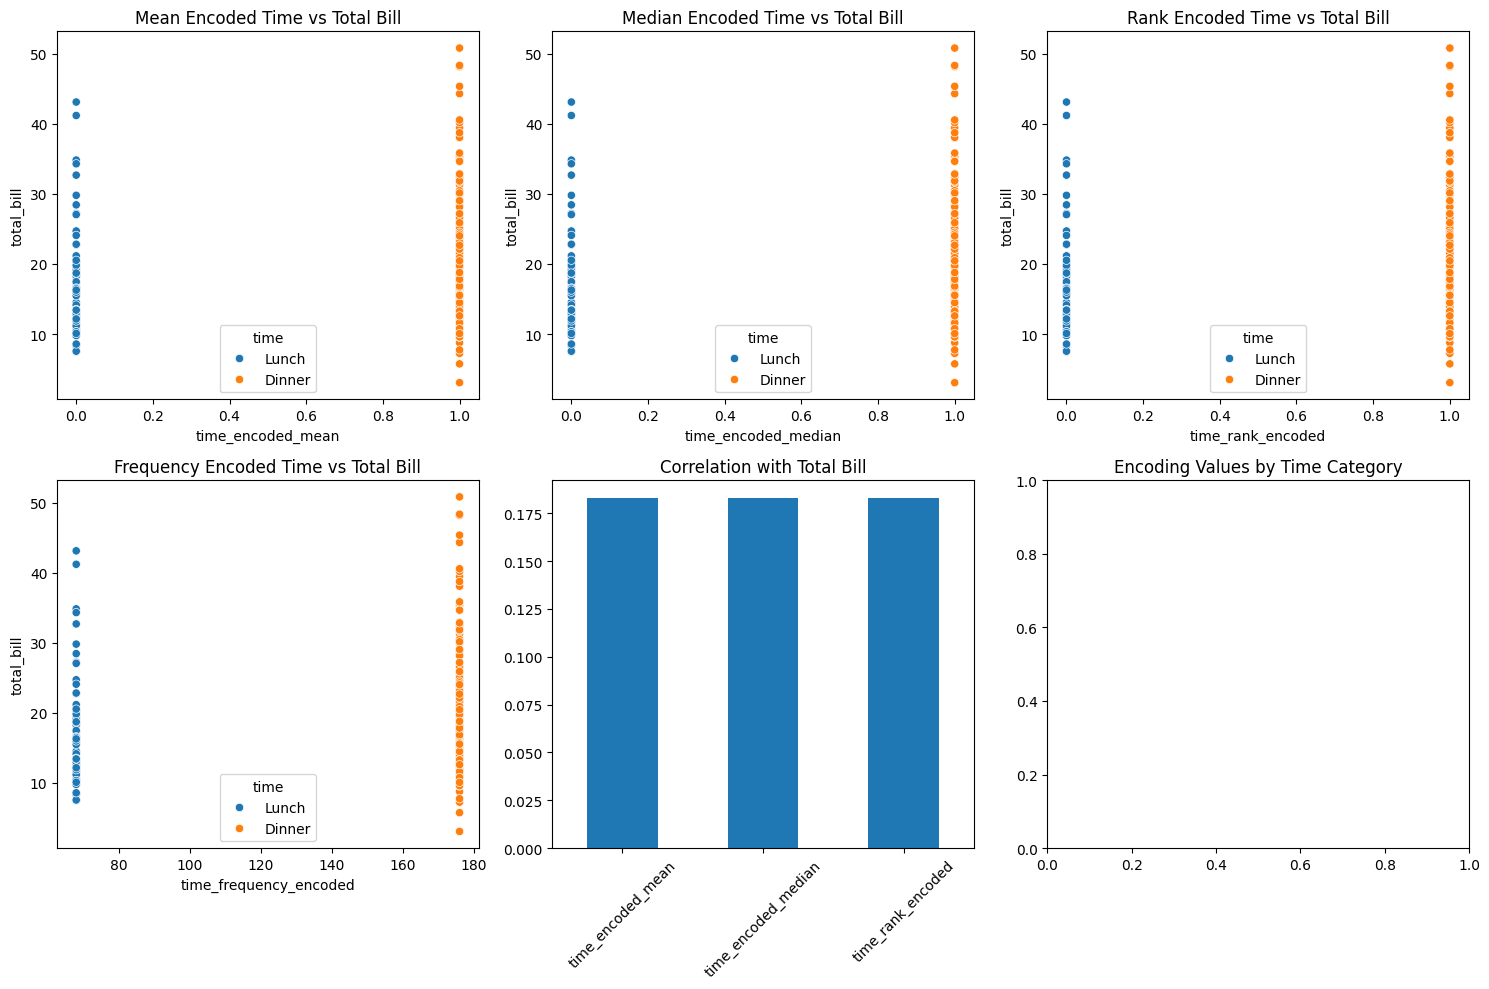

In [13]:
# Visualize the encoded results
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
sns.scatterplot(data=final_df, x='time_encoded_mean', y='total_bill', hue='time')
plt.title('Mean Encoded Time vs Total Bill')

plt.subplot(2, 3, 2)
sns.scatterplot(data=final_df, x='time_encoded_median', y='total_bill', hue='time')
plt.title('Median Encoded Time vs Total Bill')

plt.subplot(2, 3, 3)
sns.scatterplot(data=final_df, x='time_rank_encoded', y='total_bill', hue='time')
plt.title('Rank Encoded Time vs Total Bill')

plt.subplot(2, 3, 4)
sns.scatterplot(data=final_df, x='time_frequency_encoded', y='total_bill', hue='time')
plt.title('Frequency Encoded Time vs Total Bill')

plt.subplot(2, 3, 5)
final_df[['time_encoded_mean', 'time_encoded_median', 'time_rank_encoded']].corrwith(final_df['total_bill']).plot(kind='bar')
plt.title('Correlation with Total Bill')
plt.xticks(rotation=45)

plt.subplot(2, 3, 6)
encoding_comparison = final_df.groupby('time')[['time_encoded_mean', 'time_encoded_median', 'time_rank_encoded']].first()
# encoding_comparison.plot(kind='bar')
plt.title('Encoding Values by Time Category')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [11]:
# Save the encoded dataset
print("Saving the encoded dataset...")
final_df.to_csv('tips_time_encoded.csv', index=False)
print("Dataset saved as 'tips_time_encoded.csv'")

# Summary statistics
print("\nSummary of encoded time columns:")
encoded_cols = ['time_encoded_mean', 'time_encoded_median', 'time_rank_encoded', 'time_frequency_encoded']
print(final_df[encoded_cols].describe())

print("\nCorrelation matrix between encoded time columns and total_bill:")
correlation_matrix = final_df[encoded_cols + ['total_bill']].corr()
print(correlation_matrix['total_bill'].sort_values(ascending=False))

Saving the encoded dataset...
Dataset saved as 'tips_time_encoded.csv'

Summary of encoded time columns:
        time_encoded_mean  time_encoded_median  time_rank_encoded  \
count                 244                  244                244   
unique                  2                    2                  2   
top                     1                    1                  1   
freq                  176                  176                176   

        time_frequency_encoded  
count                      244  
unique                       2  
top                        176  
freq                       176  

Correlation matrix between encoded time columns and total_bill:
total_bill                1.000000
time_frequency_encoded    0.183118
time_encoded_mean         0.183118
time_encoded_median       0.183118
time_rank_encoded         0.183118
Name: total_bill, dtype: float64


In [12]:
# Practical usage example
def transform_new_data(new_data, encoding_mappings):
    """
    Function to apply the same encoding to new data
    """
    result_df = new_data.copy()
    
    # Apply the encodings
    result_df['time_encoded_mean'] = result_df['time'].map(encoding_mappings['mean'])
    result_df['time_encoded_median'] = result_df['time'].map(encoding_mappings['median'])
    result_df['time_rank_encoded'] = result_df['time'].map(encoding_mappings['rank'])
    
    return result_df

# Example of how to use the encodings on new data
new_data = pd.DataFrame({
    'time': ['Lunch', 'Dinner', 'Lunch', 'Dinner'],
    'total_bill': [15.5, 25.0, 12.0, 30.0]
})

print("New data to transform:")
print(new_data)

# Create encoding mappings from the original data
mean_mapping = {cat: idx for idx, cat in enumerate(df.groupby('time')['total_bill'].mean().sort_values().index)}
median_mapping = {cat: idx for idx, cat in enumerate(df.groupby('time')['total_bill'].median().sort_values().index)}
rank_mapping = {'Lunch': 0, 'Dinner': 1}

encoding_mappings = {
    'mean': mean_mapping,
    'median': median_mapping,
    'rank': rank_mapping
}

# Transform new data
transformed_new_data = transform_new_data(new_data, encoding_mappings)
print("\nTransformed new data:")
print(transformed_new_data)

New data to transform:
     time  total_bill
0   Lunch        15.5
1  Dinner        25.0
2   Lunch        12.0
3  Dinner        30.0

Transformed new data:
     time  total_bill  time_encoded_mean  time_encoded_median  \
0   Lunch        15.5                  0                    0   
1  Dinner        25.0                  1                    1   
2   Lunch        12.0                  0                    0   
3  Dinner        30.0                  1                    1   

   time_rank_encoded  
0                  0  
1                  1  
2                  0  
3                  1  


/var/folders/y1/44jbvlv94_5c1bldzjp1gnlh0000gn/T/ipykernel_6184/505520366.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_mapping = {cat: idx for idx, cat in enumerate(df.groupby('time')['total_bill'].mean().sort_values().index)}
/var/folders/y1/44jbvlv94_5c1bldzjp1gnlh0000gn/T/ipykernel_6184/505520366.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_mapping = {cat: idx for idx, cat in enumerate(df.groupby('time')['total_bill'].median().sort_values().index)}


## Summary

This notebook demonstrates several methods to convert the 'time' column in the tips dataset based on 'total_bill' values:

1. **Target Guided Ordinal Encoding (Mean)**: Encodes time categories based on mean total_bill values
2. **Target Guided Ordinal Encoding (Median)**: Encodes time categories based on median total_bill values
3. **Rank Encoding**: Simple ordinal encoding assuming Lunch < Dinner
4. **Frequency Encoding**: Encodes based on frequency of each time category

### Key Insights:
- The choice of encoding method depends on the relationship between time and total_bill
- Target Guided Ordinal Encoding creates a monotonic relationship with the target variable
- Different encoding methods capture different aspects of the relationship
- The encoded features can be used for machine learning models

### Usage:
- The encoded features are saved in columns: `time_encoded_mean`, `time_encoded_median`, `time_rank_encoded`
- Use `transform_new_data()` function to apply the same encoding to new data
- The correlation analysis helps choose the best encoding method for your specific use case